In [ ]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam

np.random.seed(42)
tf.random.set_seed(42)

plt.rcParams.update({
    "figure.figsize": (12, 6),
    "figure.dpi": 120,
    "figure.facecolor": "#0F172A",
    "axes.facecolor": "#111827",
    "axes.edgecolor": "#475569",
    "axes.labelcolor": "#E5E7EB",
    "axes.titlecolor": "#F8FAFC",
    "xtick.color": "#CBD5E1",
    "ytick.color": "#CBD5E1",
    "text.color": "#F8FAFC",
    "grid.color": "#334155",
    "grid.alpha": 0.35,
    "grid.linestyle": "--",
    "legend.facecolor": "#1E293B",
    "legend.edgecolor": "#475569",
    "font.size": 12,
    "axes.titleweight": "bold"
})

COLORS = {
    "pink": "#F472B6",
    "purple": "#A78BFA",
    "cyan": "#22D3EE",
    "blue": "#60A5FA",
    "green": "#34D399",
    "orange": "#FB923C",
    "yellow": "#FACC15",
    "red": "#FB7185",
    "white": "#F8FAFC",
    "muted": "#94A3B8"
}

In [ ]:
X_train = np.linspace(-1, 1, 20).reshape(-1, 1)

y_train = np.array([
    -0.6561, -0.3099, -0.59035, -0.50855, -0.285,
    -0.2443, -0.02445, 0.00135, -0.2006, 0.07475,
    -0.1422, 0.06515, 0.15265, 0.3521, 0.28415,
    0.5524, 0.23115, 0.20835, 0.4211, 0.60485
])

X_test = np.linspace(-1, 1, 20).reshape(-1, 1)

y_test = np.array([
    -0.69415, -0.451, -0.43005, -0.4484, -0.1475,
    -0.5019, -0.28055, 0.24595, -0.21425, -0.0286,
    0.23415, 0.46575, 0.07955, 0.1973, 0.0719,
    0.3639, 0.5536, 0.3365, 0.50705, 0.33435
])

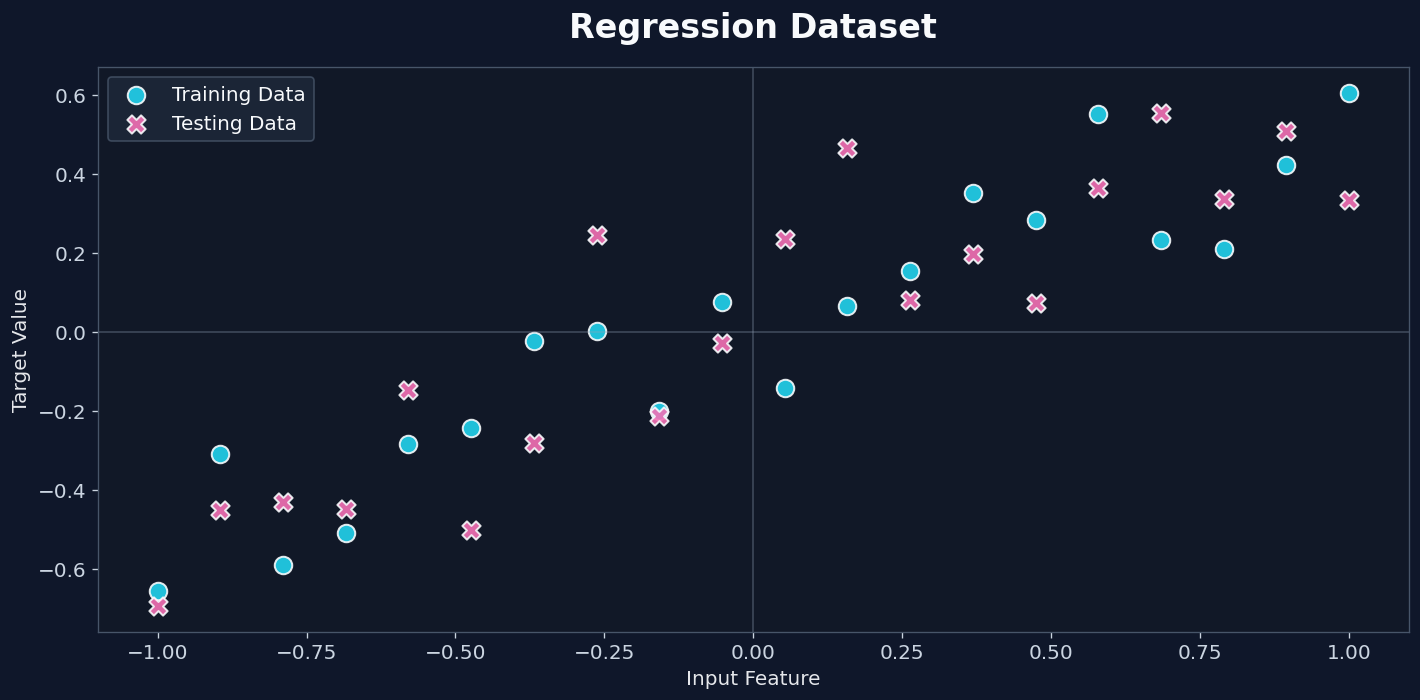

In [ ]:
fig, ax = plt.subplots(figsize=(12, 6))

ax.scatter(
    X_train[:, 0],
    y_train,
    s=110,
    c=COLORS["cyan"],
    alpha=0.9,
    edgecolor=COLORS["white"],
    linewidth=1.2,
    label="Training Data"
)

ax.scatter(
    X_test[:, 0],
    y_test,
    s=120,
    c=COLORS["pink"],
    alpha=0.9,
    marker="X",
    edgecolor=COLORS["white"],
    linewidth=1.2,
    label="Testing Data"
)

ax.axhline(
    0,
    color=COLORS["muted"],
    linewidth=1,
    alpha=0.35
)

ax.axvline(
    0,
    color=COLORS["muted"],
    linewidth=1,
    alpha=0.35
)

ax.set_title("Regression Dataset", fontsize=20, pad=18)
ax.set_xlabel("Input Feature")
ax.set_ylabel("Target Value")

ax.legend(
    loc="upper left",
    frameon=True
)

plt.tight_layout()
plt.show()

In [ ]:
model_reg_base = Sequential([
    Dense(128, input_dim=1, activation="relu"),
    Dense(128, activation="relu"),
    Dense(1, activation="linear")
])

model_reg_base.compile(
    optimizer=Adam(learning_rate=0.01),
    loss="mse",
    metrics=["mse"]
)

model_reg_base.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,897 (66.00 KB)

 Trainable params: 16,897 (66.00 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history_reg_base = model_reg_base.fit(
    X_train,
    y_train,
    epochs=500,
    validation_data=(X_test, y_test),
    verbose=0
)

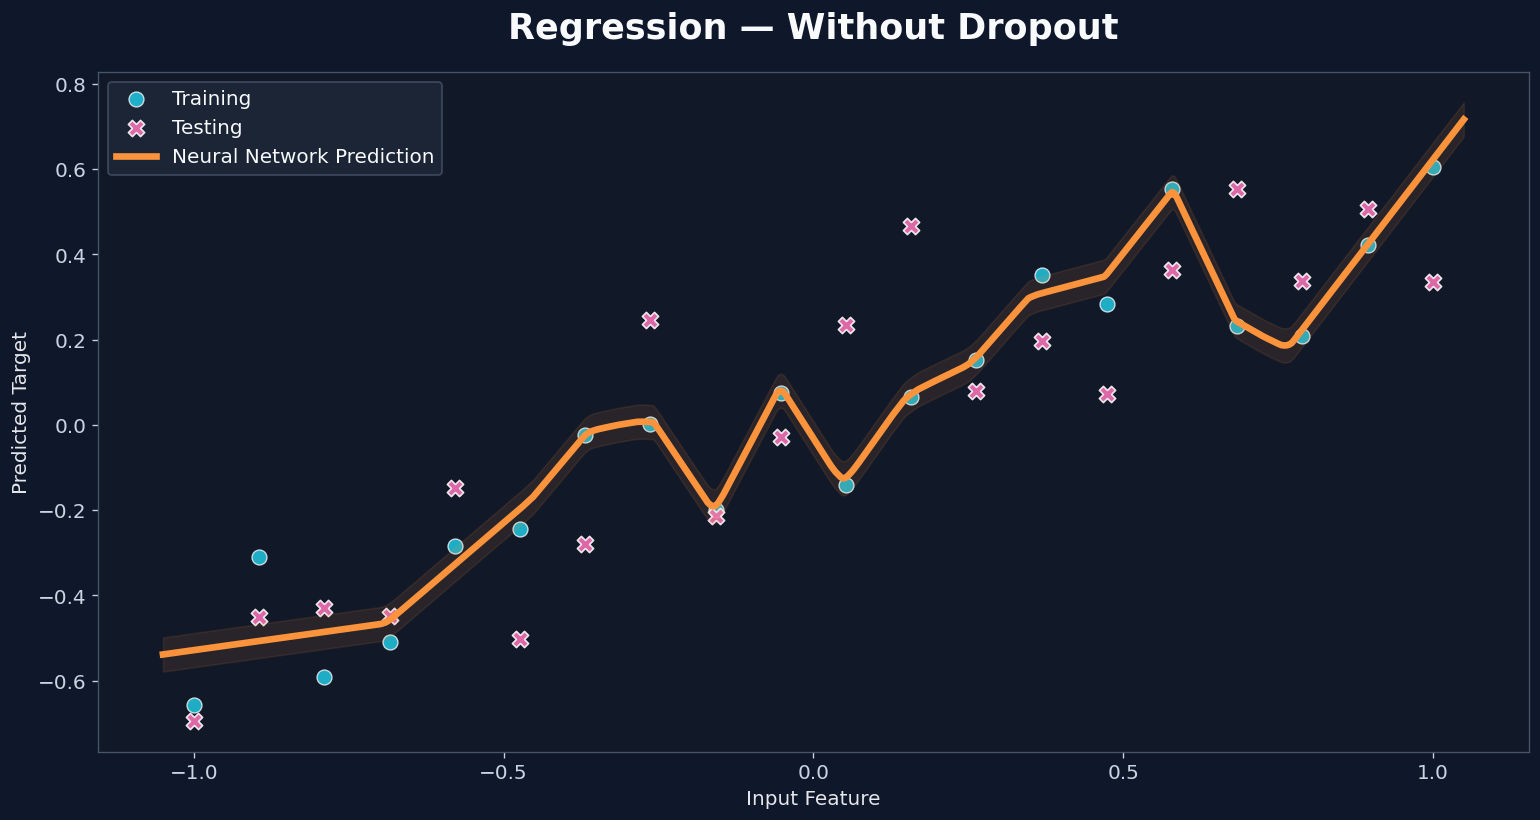

In [ ]:
X_curve = np.linspace(
    X_test.min() - 0.05,
    X_test.max() + 0.05,
    500
).reshape(-1, 1)

y_curve_base = model_reg_base.predict(
    X_curve,
    verbose=0
).ravel()

fig, ax = plt.subplots(figsize=(13, 7))

ax.scatter(
    X_train[:, 0],
    y_train,
    s=80,
    c=COLORS["cyan"],
    alpha=0.8,
    edgecolor=COLORS["white"],
    linewidth=0.8,
    label="Training"
)

ax.scatter(
    X_test[:, 0],
    y_test,
    s=95,
    c=COLORS["pink"],
    marker="X",
    alpha=0.9,
    edgecolor=COLORS["white"],
    linewidth=1,
    label="Testing"
)

ax.plot(
    X_curve[:, 0],
    y_curve_base,
    color=COLORS["orange"],
    linewidth=4,
    label="Neural Network Prediction"
)

ax.fill_between(
    X_curve[:, 0],
    y_curve_base - 0.04,
    y_curve_base + 0.04,
    color=COLORS["orange"],
    alpha=0.10
)

ax.set_title(
    "Regression — Without Dropout",
    fontsize=21,
    pad=20
)

ax.set_xlabel("Input Feature")
ax.set_ylabel("Predicted Target")

ax.legend(frameon=True)

plt.tight_layout()
plt.show()

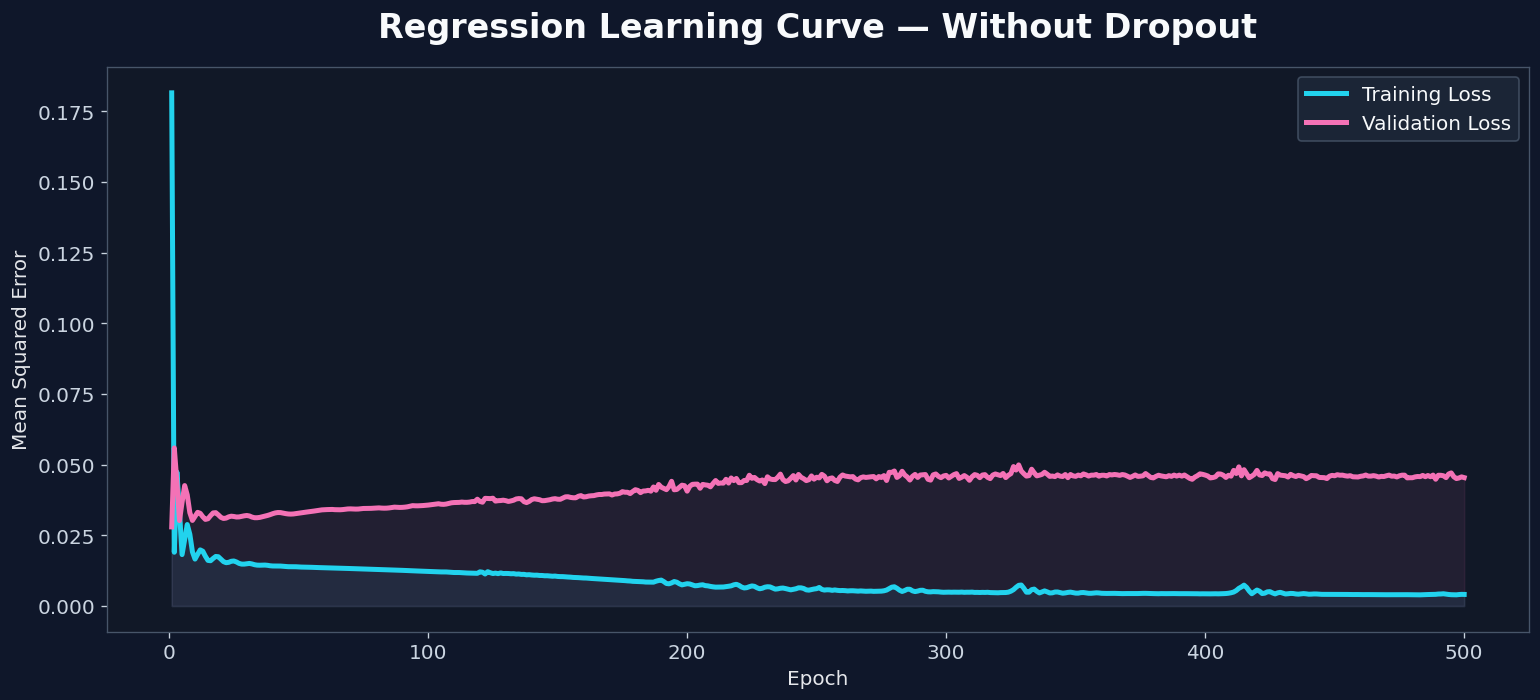

In [ ]:
fig, ax = plt.subplots(figsize=(13, 6))

epochs = np.arange(1, len(history_reg_base.history["loss"]) + 1)

ax.plot(
    epochs,
    history_reg_base.history["loss"],
    color=COLORS["cyan"],
    linewidth=3,
    label="Training Loss"
)

ax.plot(
    epochs,
    history_reg_base.history["val_loss"],
    color=COLORS["pink"],
    linewidth=3,
    label="Validation Loss"
)

ax.fill_between(
    epochs,
    history_reg_base.history["loss"],
    alpha=0.08,
    color=COLORS["cyan"]
)

ax.fill_between(
    epochs,
    history_reg_base.history["val_loss"],
    alpha=0.08,
    color=COLORS["pink"]
)

ax.set_title(
    "Regression Learning Curve — Without Dropout",
    fontsize=20,
    pad=18
)

ax.set_xlabel("Epoch")
ax.set_ylabel("Mean Squared Error")

ax.legend(frameon=True)

plt.tight_layout()
plt.show()

In [ ]:
reg_dropout_rate = 0.20

model_reg_dropout = Sequential([
    Dense(128, input_dim=1, activation="relu"),
    Dropout(reg_dropout_rate),
    Dense(128, activation="relu"),
    Dropout(reg_dropout_rate),
    Dense(1, activation="linear")
])

model_reg_dropout.compile(
    optimizer=Adam(learning_rate=0.01),
    loss="mse",
    metrics=["mse"]
)

model_reg_dropout.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 128)            │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,897 (66.00 KB)

 Trainable params: 16,897 (66.00 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history_reg_dropout = model_reg_dropout.fit(
    X_train,
    y_train,
    epochs=500,
    validation_data=(X_test, y_test),
    verbose=0
)

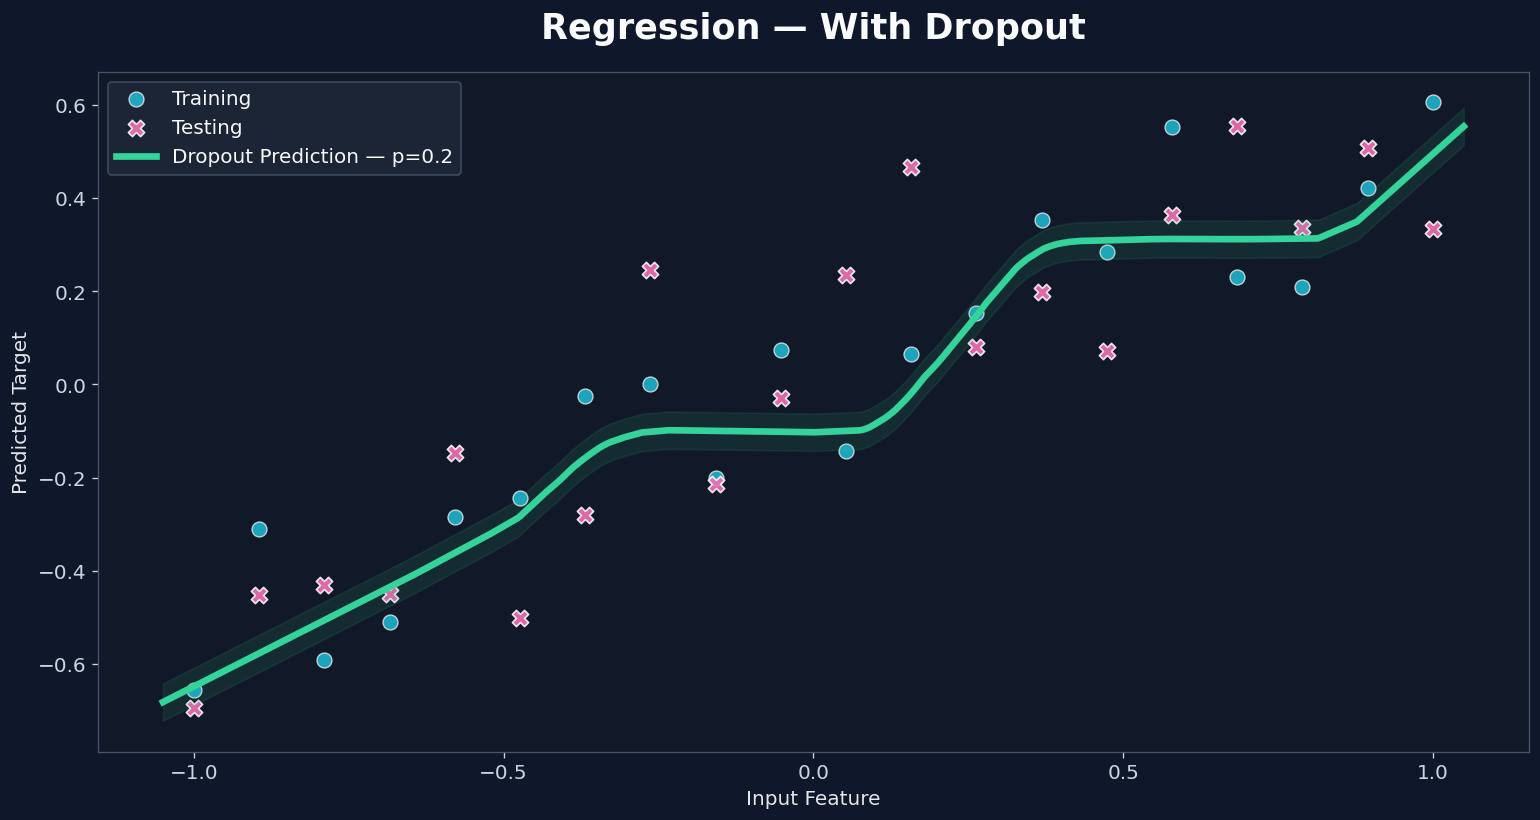

In [ ]:
y_curve_dropout = model_reg_dropout.predict(
    X_curve,
    verbose=0
).ravel()

fig, ax = plt.subplots(figsize=(13, 7))

ax.scatter(
    X_train[:, 0],
    y_train,
    s=80,
    c=COLORS["cyan"],
    alpha=0.75,
    edgecolor=COLORS["white"],
    linewidth=0.8,
    label="Training"
)

ax.scatter(
    X_test[:, 0],
    y_test,
    s=95,
    c=COLORS["pink"],
    marker="X",
    alpha=0.9,
    edgecolor=COLORS["white"],
    linewidth=1,
    label="Testing"
)

ax.plot(
    X_curve[:, 0],
    y_curve_dropout,
    color=COLORS["green"],
    linewidth=4,
    label=f"Dropout Prediction — p={reg_dropout_rate}"
)

ax.fill_between(
    X_curve[:, 0],
    y_curve_dropout - 0.04,
    y_curve_dropout + 0.04,
    color=COLORS["green"],
    alpha=0.10
)

ax.set_title(
    "Regression — With Dropout",
    fontsize=21,
    pad=20
)

ax.set_xlabel("Input Feature")
ax.set_ylabel("Predicted Target")

ax.legend(frameon=True)

plt.tight_layout()
plt.show()

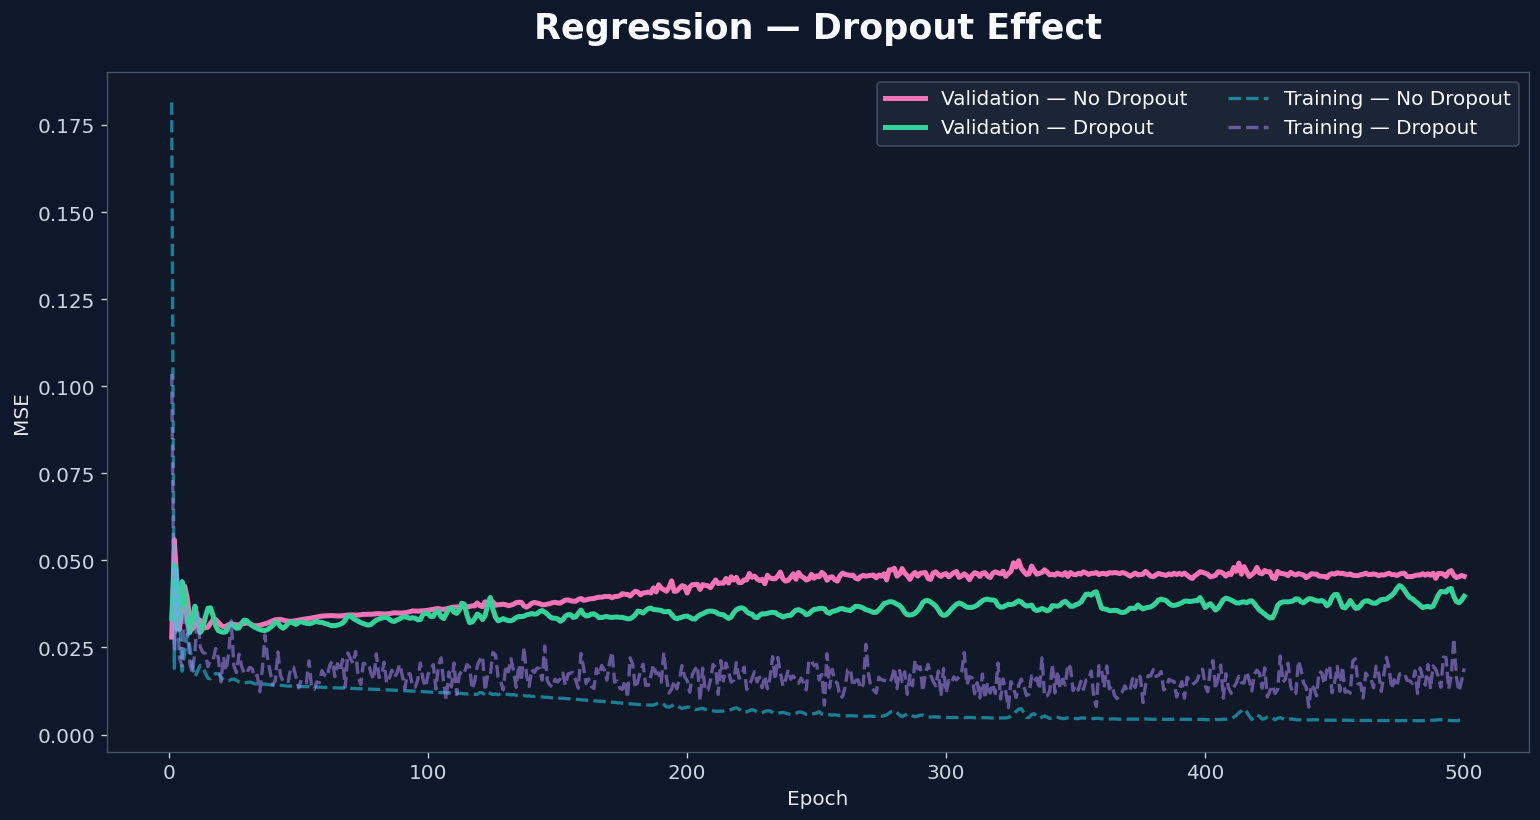

In [ ]:
fig, ax = plt.subplots(figsize=(13, 7))

epochs_base = np.arange(
    1,
    len(history_reg_base.history["loss"]) + 1
)

epochs_drop = np.arange(
    1,
    len(history_reg_dropout.history["loss"]) + 1
)

ax.plot(
    epochs_base,
    history_reg_base.history["val_loss"],
    color=COLORS["pink"],
    linewidth=3,
    label="Validation — No Dropout"
)

ax.plot(
    epochs_drop,
    history_reg_dropout.history["val_loss"],
    color=COLORS["green"],
    linewidth=3,
    label="Validation — Dropout"
)

ax.plot(
    epochs_base,
    history_reg_base.history["loss"],
    color=COLORS["cyan"],
    linewidth=2,
    alpha=0.55,
    linestyle="--",
    label="Training — No Dropout"
)

ax.plot(
    epochs_drop,
    history_reg_dropout.history["loss"],
    color=COLORS["purple"],
    linewidth=2,
    alpha=0.55,
    linestyle="--",
    label="Training — Dropout"
)

ax.set_title(
    "Regression — Dropout Effect",
    fontsize=21,
    pad=20
)

ax.set_xlabel("Epoch")
ax.set_ylabel("MSE")

ax.legend(
    frameon=True,
    ncol=2
)

plt.tight_layout()
plt.show()

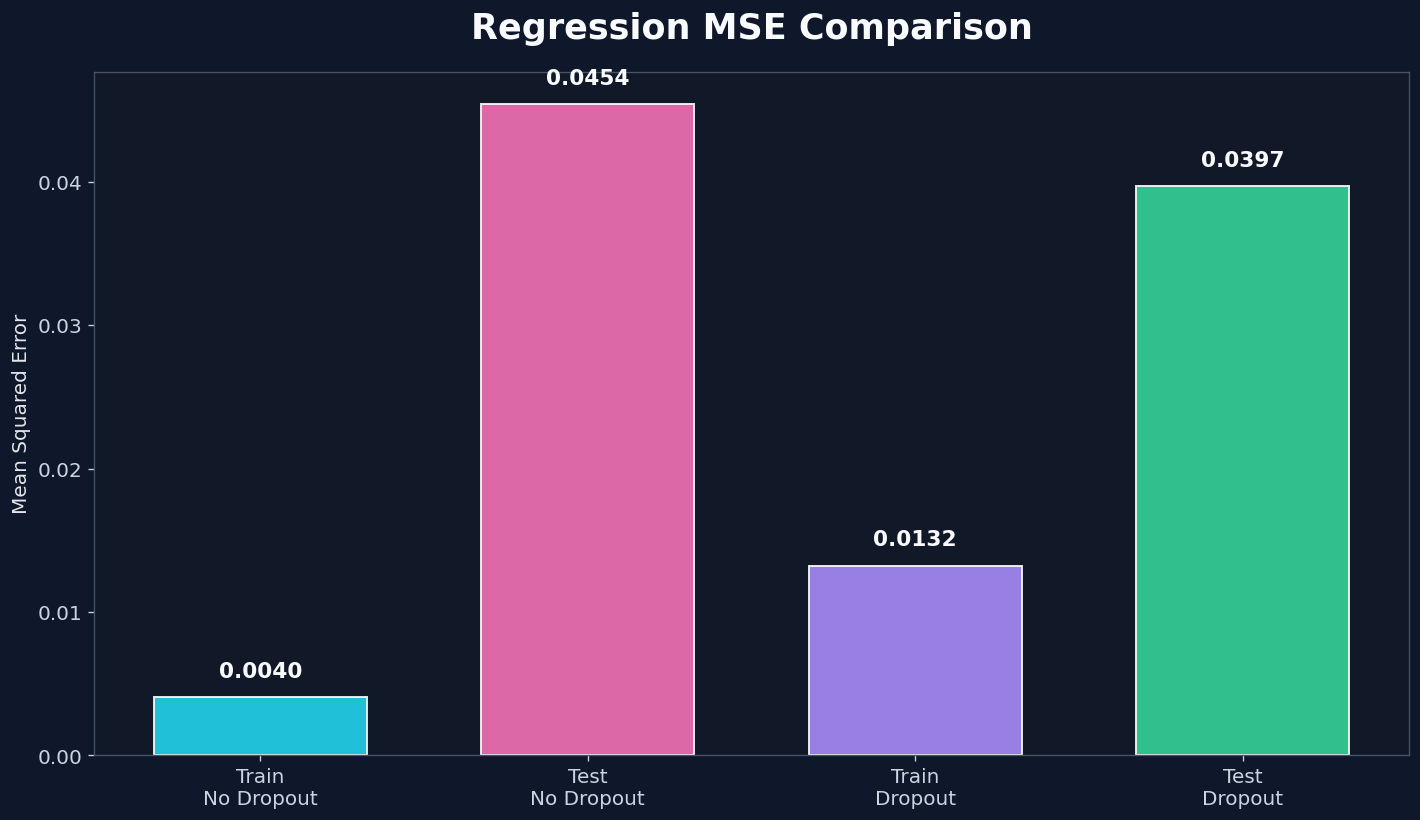

Baseline Test MSE : 0.045418
Dropout Test MSE  : 0.039707
Improvement       : 12.58%


In [ ]:
train_mse_base = model_reg_base.evaluate(
    X_train,
    y_train,
    verbose=0
)[1]

test_mse_base = model_reg_base.evaluate(
    X_test,
    y_test,
    verbose=0
)[1]

train_mse_dropout = model_reg_dropout.evaluate(
    X_train,
    y_train,
    verbose=0
)[1]

test_mse_dropout = model_reg_dropout.evaluate(
    X_test,
    y_test,
    verbose=0
)[1]

labels = [
    "Train\nNo Dropout",
    "Test\nNo Dropout",
    "Train\nDropout",
    "Test\nDropout"
]

values = [
    train_mse_base,
    test_mse_base,
    train_mse_dropout,
    test_mse_dropout
]

bar_colors = [
    COLORS["cyan"],
    COLORS["pink"],
    COLORS["purple"],
    COLORS["green"]
]

fig, ax = plt.subplots(figsize=(12, 7))

bars = ax.bar(
    labels,
    values,
    color=bar_colors,
    width=0.65,
    alpha=0.9,
    edgecolor=COLORS["white"],
    linewidth=1.2
)

for bar, value in zip(bars, values):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + max(values) * 0.025,
        f"{value:.4f}",
        ha="center",
        va="bottom",
        fontsize=13,
        fontweight="bold"
    )

ax.set_title(
    "Regression MSE Comparison",
    fontsize=21,
    pad=20
)

ax.set_ylabel("Mean Squared Error")

plt.tight_layout()
plt.show()

print(f"Baseline Test MSE : {test_mse_base:.6f}")
print(f"Dropout Test MSE  : {test_mse_dropout:.6f}")
print(
    f"Improvement       : "
    f"{((test_mse_base - test_mse_dropout) / test_mse_base) * 100:.2f}%"
)

In [ ]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

np.random.seed(42)
tf.random.set_seed(42)

plt.rcParams.update({
    "figure.figsize": (12, 7),
    "figure.dpi": 120,
    "figure.facecolor": "#0F172A",
    "axes.facecolor": "#111827",
    "axes.edgecolor": "#475569",
    "axes.labelcolor": "#E5E7EB",
    "axes.titlecolor": "#F8FAFC",
    "xtick.color": "#CBD5E1",
    "ytick.color": "#CBD5E1",
    "text.color": "#F8FAFC",
    "grid.color": "#334155",
    "grid.alpha": 0.35,
    "grid.linestyle": "--",
    "legend.facecolor": "#1E293B",
    "legend.edgecolor": "#475569",
    "font.size": 12,
    "axes.titleweight": "bold"
})

COLORS = {
    "pink": "#F472B6",
    "purple": "#A78BFA",
    "cyan": "#22D3EE",
    "blue": "#60A5FA",
    "green": "#34D399",
    "orange": "#FB923C",
    "yellow": "#FACC15",
    "red": "#FB7185",
    "white": "#F8FAFC",
    "muted": "#94A3B8"
}

In [ ]:
X = np.array([[-1.58986e-01,  4.23977e-01],
       [-3.47926e-01,  4.70760e-01],
       [-5.04608e-01,  3.53801e-01],
       [-5.96774e-01,  1.14035e-01],
       [-5.18433e-01, -1.72515e-01],
       [-2.92627e-01, -2.07602e-01],
       [-1.58986e-01, -4.38596e-02],
       [-5.76037e-02,  1.43275e-01],
       [-7.14286e-02,  2.71930e-01],
       [-2.97235e-01,  3.47953e-01],
       [-4.17051e-01,  2.01754e-01],
       [-4.40092e-01,  8.77193e-03],
       [-3.24885e-01, -3.21637e-02],
       [-2.46544e-01,  5.55556e-02],
       [-2.18894e-01,  2.01754e-01],
       [-3.43318e-01,  1.60819e-01],
       [-5.09217e-01,  7.89474e-02],
       [-3.84793e-01, -9.06433e-02],
       [-1.49770e-01,  1.25731e-01],
       [-1.95853e-01,  3.24561e-01],
       [-3.91705e-02, -2.19298e-01],
       [-1.08295e-01, -3.01170e-01],
       [-1.86636e-01, -3.30409e-01],
       [-2.18894e-01, -4.23977e-01],
       [-8.06452e-02, -5.64327e-01],
       [ 6.68203e-02, -5.17544e-01],
       [ 9.44700e-02, -3.24561e-01],
       [ 1.86636e-01, -1.66667e-01],
       [ 6.22120e-02, -7.30994e-02],
       [ 2.07373e-02, -1.95906e-01],
       [ 2.99539e-02, -3.42105e-01],
       [-9.90783e-02, -3.77193e-01],
       [-6.91244e-03, -4.64912e-01],
       [ 1.31336e-01, -4.29825e-01],
       [ 2.32719e-01, -1.95906e-01],
       [ 8.52535e-02, -8.47953e-02],
       [-1.31336e-01, -2.36842e-01],
       [ 2.30415e-03, -1.25731e-01],
       [ 1.22120e-01, -2.92398e-03],
       [-3.47926e-01, -3.12865e-01],
       [-2.28111e-01, -1.25731e-01],
       [-7.60369e-02,  1.46199e-02],
       [ 4.37788e-02,  2.04678e-02],
       [ 1.15207e-02,  1.54971e-01],
       [-4.17051e-01, -1.60819e-01],
       [-3.15668e-01, -3.18713e-01],
       [ 1.26728e-01, -2.19298e-01],
       [ 2.05069e-01, -3.12865e-01],
       [ 2.18894e-01, -4.59064e-01],
       [ 7.14286e-02, -6.46199e-01],
       [-1.31336e-01, -6.05263e-01],
       [-2.09677e-01, -5.81871e-01],
       [-2.28111e-01, -4.29825e-01],
       [-1.45161e-01, -4.12281e-01],
       [-6.68203e-02, -4.82456e-01],
       [ 1.35945e-01, -5.11696e-01],
       [ 2.69585e-01, -4.06433e-01],
       [ 2.97235e-01, -2.95322e-01],
       [ 2.74194e-01, -1.72515e-01],
       [ 2.55760e-01, -4.97076e-02],
       [ 2.23502e-01, -4.97076e-02],
       [ 1.82028e-01, -8.47953e-02],
       [ 1.58986e-01, -1.54971e-01],
       [ 7.14286e-02, -2.13450e-01],
       [ 1.61290e-02, -2.66082e-01],
       [-2.53456e-02, -3.83041e-01],
       [-1.15207e-02, -4.82456e-01],
       [-2.30415e-03, -5.05848e-01],
       [ 2.53456e-02, -5.11696e-01],
       [ 2.53456e-02, -5.58480e-01],
       [ 1.15207e-02, -6.57895e-01],
       [-4.83871e-02, -6.46199e-01],
       [-8.52535e-02, -5.52632e-01],
       [-9.90783e-02, -5.00000e-01],
       [-1.61290e-02, -4.23977e-01],
       [ 1.31336e-01, -3.59649e-01],
       [ 2.23502e-01, -3.71345e-01],
       [ 2.92627e-01, -3.01170e-01],
       [ 2.60369e-01, -2.07602e-01],
       [ 2.00461e-01, -2.25146e-01],
       [ 1.72811e-01, -2.71930e-01],
       [-1.31336e-01,  9.06433e-02],
       [-1.49770e-01,  7.30994e-02],
       [-2.41935e-01,  6.14035e-02],
       [-3.01843e-01,  1.78363e-01],
       [-2.97235e-01,  1.95906e-01],
       [-2.74194e-01,  3.07018e-01],
       [-3.24885e-01,  2.95322e-01],
       [-3.98618e-01,  2.66082e-01],
       [-4.35484e-01,  1.60819e-01],
       [-4.72350e-01,  7.89474e-02],
       [-3.38710e-01,  4.38596e-02],
       [-2.69585e-01,  4.38596e-02],
       [-2.55760e-01,  1.02339e-01],
       [-1.68203e-01,  2.66082e-01],
       [-1.12903e-01,  3.01170e-01],
       [-3.91705e-02,  3.47953e-01],
       [-1.26728e-01,  4.41520e-01],
       [-2.32719e-01,  4.41520e-01],
       [-3.38710e-01,  4.18129e-01],
       [-4.12442e-01,  3.53801e-01],
       [-5.09217e-01,  2.19298e-01],
       [-5.41475e-01,  1.46199e-02],
       [-5.04608e-01, -1.25731e-01],
       [-4.90783e-01, -1.43275e-01],
       [-3.61751e-01, -1.37427e-01],
       [-2.69585e-01, -8.47953e-02],
       [-2.23502e-01, -7.89474e-02],
       [-1.86636e-01, -3.80117e-02],
       [-1.54378e-01, -8.77193e-03],
       [-1.12903e-01,  5.55556e-02],
       [-8.52535e-02,  1.37427e-01],
       [-8.52535e-02,  2.77778e-01],
       [-1.68203e-01,  3.01170e-01],
       [-1.91244e-01,  1.95906e-01],
       [-1.40553e-01, -4.97076e-02],
       [-2.99539e-02,  6.72515e-02],
       [-2.00461e-01, -2.30994e-01],
       [-1.08295e-01, -8.47953e-02],
       [ 3.45622e-02,  6.72515e-02],
       [ 8.06452e-02,  1.19883e-01],
       [-3.85369e-01,  3.30409e-02],
       [-3.81221e-01,  1.31287e-01],
       [-3.52189e-01,  2.58187e-01],
       [-3.54263e-01,  3.64620e-01],
       [-4.14401e-01, -6.92982e-02],
       [-4.99424e-01, -3.24561e-02],
       [-2.98272e-01, -9.79532e-02],
       [-3.16935e-01, -1.83918e-01],
       [-3.68779e-01, -2.90351e-01],
       [-3.56336e-01, -3.96784e-01],
       [-2.71313e-01,  4.38596e-03],
       [-1.77995e-01,  8.62573e-02],
       [-2.46429e-01,  1.43567e-01],
       [-2.50576e-01,  2.29532e-01],
       [-2.21544e-01,  3.76901e-01],
       [-2.15323e-01,  2.95029e-01],
       [-1.30300e-01,  2.17251e-01],
       [-2.07028e-01,  2.89474e-02],
       [-9.71198e-02,  2.13158e-01],
       [-3.90553e-02,  2.58187e-01],
       [ 1.90092e-02,  4.01462e-01],
       [-3.69816e-02,  4.21930e-01],
       [-6.39401e-02,  3.31871e-01],
       [-1.30300e-01,  3.76901e-01],
       [-3.75000e-01, -4.37719e-01],
       [-3.95737e-01, -3.51754e-01],
       [-3.54263e-01, -2.08480e-01],
       [-4.37212e-01, -3.76316e-01],
       [-4.80760e-01, -5.03216e-01],
       [-4.10253e-01, -4.66374e-01],
       [-2.48502e-01, -2.57602e-01],
       [-2.27765e-01, -3.14912e-01],
       [-2.83756e-01, -3.84503e-01],
       [-2.92051e-01, -4.54094e-01],
       [-3.37673e-01, -5.19591e-01],
       [-2.77535e-01, -5.48246e-01],
       [-2.07028e-01, -5.35965e-01],
       [-1.86290e-01, -4.78655e-01],
       [-1.32373e-01, -5.07310e-01],
       [-1.77995e-01, -2.98538e-01],
       [-1.65553e-01, -1.75731e-01],
       [-1.61406e-01, -1.26608e-01],
       [ 3.45622e-04,  2.58187e-01],
       [ 7.91475e-02,  3.56433e-01],
       [-2.66129e-02,  1.80409e-01],
       [-5.35714e-02,  7.80702e-02],
       [-1.41705e-02, -5.29240e-02],
       [-7.01613e-02, -1.63450e-01],
       [-6.39401e-02, -2.94444e-01],
       [-3.07604e-02, -4.66374e-01],
       [-5.77189e-02, -5.27778e-01],
       [-5.35714e-02, -3.96784e-01],
       [ 5.21889e-02, -4.17251e-01],
       [-1.62442e-02, -1.67544e-01],
       [-6.39401e-02, -8.56725e-02],
       [-6.18664e-02, -1.60819e-02],
       [-3.80184e-03,  4.38596e-03],
       [ 4.18203e-02,  2.04971e-01],
       [ 7.91475e-02,  1.92690e-01],
       [ 4.59677e-02,  2.54094e-01],
       [ 1.18548e-01,  1.92690e-01],
       [ 1.10253e-01,  8.62573e-02],
       [ 1.08180e-01, -6.92982e-02],
       [ 1.66244e-01, -2.42690e-02],
       [ 1.41359e-01,  6.57895e-02],
       [ 1.43433e-01,  1.68129e-01],
       [ 1.70392e-01,  1.92690e-01],
       [ 1.08180e-01,  2.99123e-01],
       [ 1.18548e-01,  3.19591e-01],
       [ 1.26843e-01,  3.93275e-01],
       [-8.67512e-02,  4.21930e-01],
       [-4.73502e-02,  5.07895e-01],
       [ 2.52304e-02,  5.20175e-01],
       [ 6.25576e-02,  5.52924e-01],
       [-5.87558e-03,  4.42398e-01],
       [-5.14977e-02,  5.73392e-01],
       [-8.05300e-02,  5.07895e-01],
       [-1.53111e-01,  5.52924e-01],
       [-1.11636e-01,  5.48830e-01],
       [-1.63479e-01,  4.91520e-01],
       [-2.52650e-01, -1.88012e-01],
       [-2.46429e-01, -3.65497e-02],
       [-3.21083e-01, -4.33626e-01],
       [-3.31452e-01, -6.05556e-01],
       [-3.85369e-01, -5.15497e-01],
       [-3.99885e-01, -6.21930e-01],
       [-1.24078e-01, -1.26608e-01],
       [-3.16935e-01, -2.28947e-01],
       [-2.94124e-01, -1.34795e-01],
       [-1.53111e-01,  1.84503e-01]])

In [ ]:
y = np.array([1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 1., 1., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 0., 0.,
       0., 0., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       0., 1., 1., 1., 1., 0., 0.])

In [ ]:
print("X shape:", X.shape)
print("y shape:", y.shape)
print("Number of samples:", len(X))
print("Number of features:", X.shape[1])
print("Classes:", np.unique(y))
print("Class distribution:", np.bincount(y.astype(int)))

X shape: (211, 2)
y shape: (211,)
Number of samples: 211
Number of features: 2
Classes: [0. 1.]
Class distribution: [105 106]


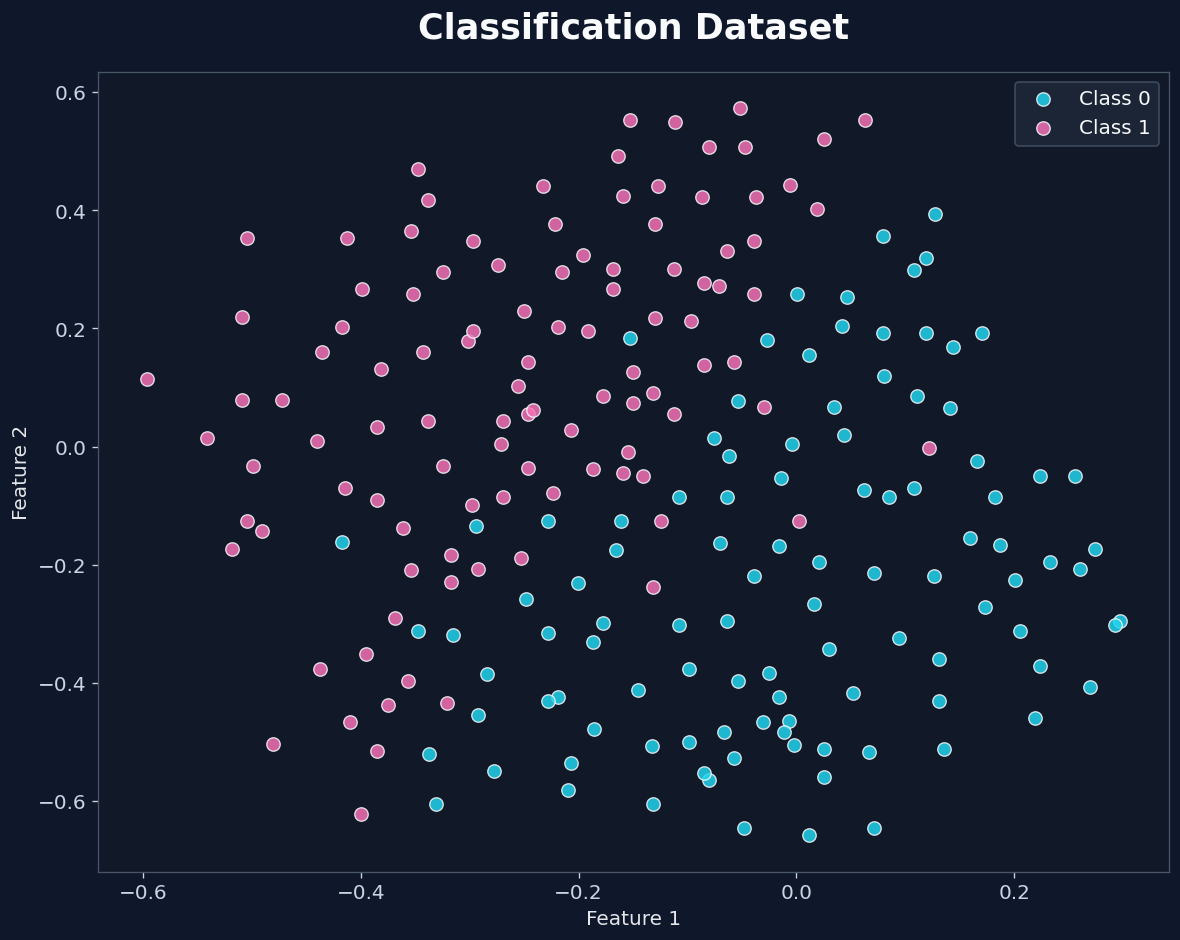

In [ ]:
class_0 = y.astype(int) == 0
class_1 = y.astype(int) == 1

fig, ax = plt.subplots(figsize=(10, 8))

ax.scatter(
    X[class_0, 0],
    X[class_0, 1],
    s=65,
    c=COLORS["cyan"],
    alpha=0.85,
    edgecolor=COLORS["white"],
    linewidth=0.8,
    label="Class 0"
)

ax.scatter(
    X[class_1, 0],
    X[class_1, 1],
    s=65,
    c=COLORS["pink"],
    alpha=0.85,
    edgecolor=COLORS["white"],
    linewidth=0.8,
    label="Class 1"
)

ax.set_title(
    "Classification Dataset",
    fontsize=21,
    pad=20
)

ax.set_xlabel("Feature 1")
ax.set_ylabel("Feature 2")

ax.legend(frameon=True)

plt.tight_layout()
plt.show()

In [ ]:
model_cls_base = Sequential([
    Dense(128, input_dim=2, activation="relu"),
    Dense(128, activation="relu"),
    Dense(1, activation="sigmoid")
])

model_cls_base.compile(
    optimizer=Adam(learning_rate=0.01),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

model_cls_base.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                 │ (None, 128)            │           384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,025 (66.50 KB)

 Trainable params: 17,025 (66.50 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history_cls_base = model_cls_base.fit(
    X,
    y,
    epochs=500,
    validation_split=0.2,
    verbose=0
)

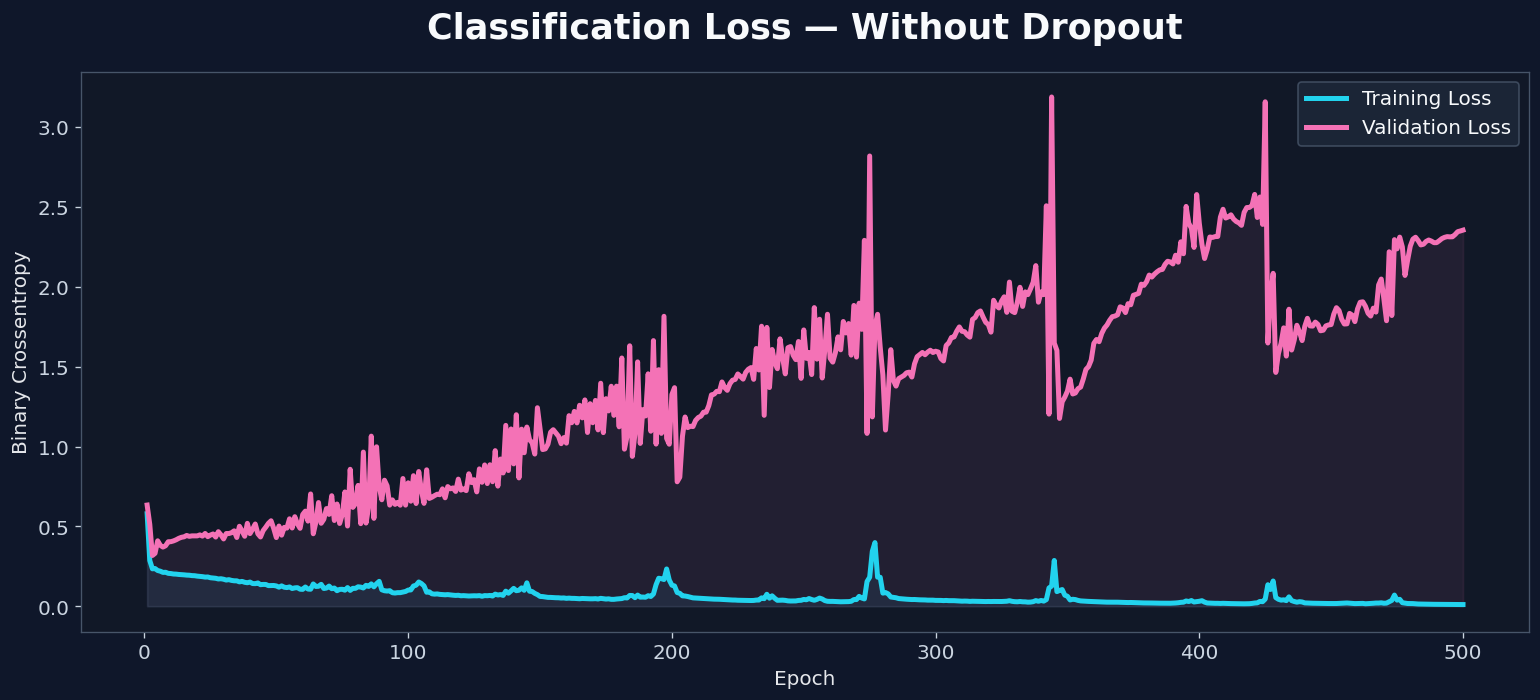

In [ ]:
epochs_cls = np.arange(
    1,
    len(history_cls_base.history["loss"]) + 1
)

fig, ax = plt.subplots(figsize=(13, 6))

ax.plot(
    epochs_cls,
    history_cls_base.history["loss"],
    color=COLORS["cyan"],
    linewidth=3,
    label="Training Loss"
)

ax.plot(
    epochs_cls,
    history_cls_base.history["val_loss"],
    color=COLORS["pink"],
    linewidth=3,
    label="Validation Loss"
)

ax.fill_between(
    epochs_cls,
    history_cls_base.history["loss"],
    alpha=0.08,
    color=COLORS["cyan"]
)

ax.fill_between(
    epochs_cls,
    history_cls_base.history["val_loss"],
    alpha=0.08,
    color=COLORS["pink"]
)

ax.set_title(
    "Classification Loss — Without Dropout",
    fontsize=21,
    pad=20
)

ax.set_xlabel("Epoch")
ax.set_ylabel("Binary Crossentropy")

ax.legend(frameon=True)

plt.tight_layout()
plt.show()

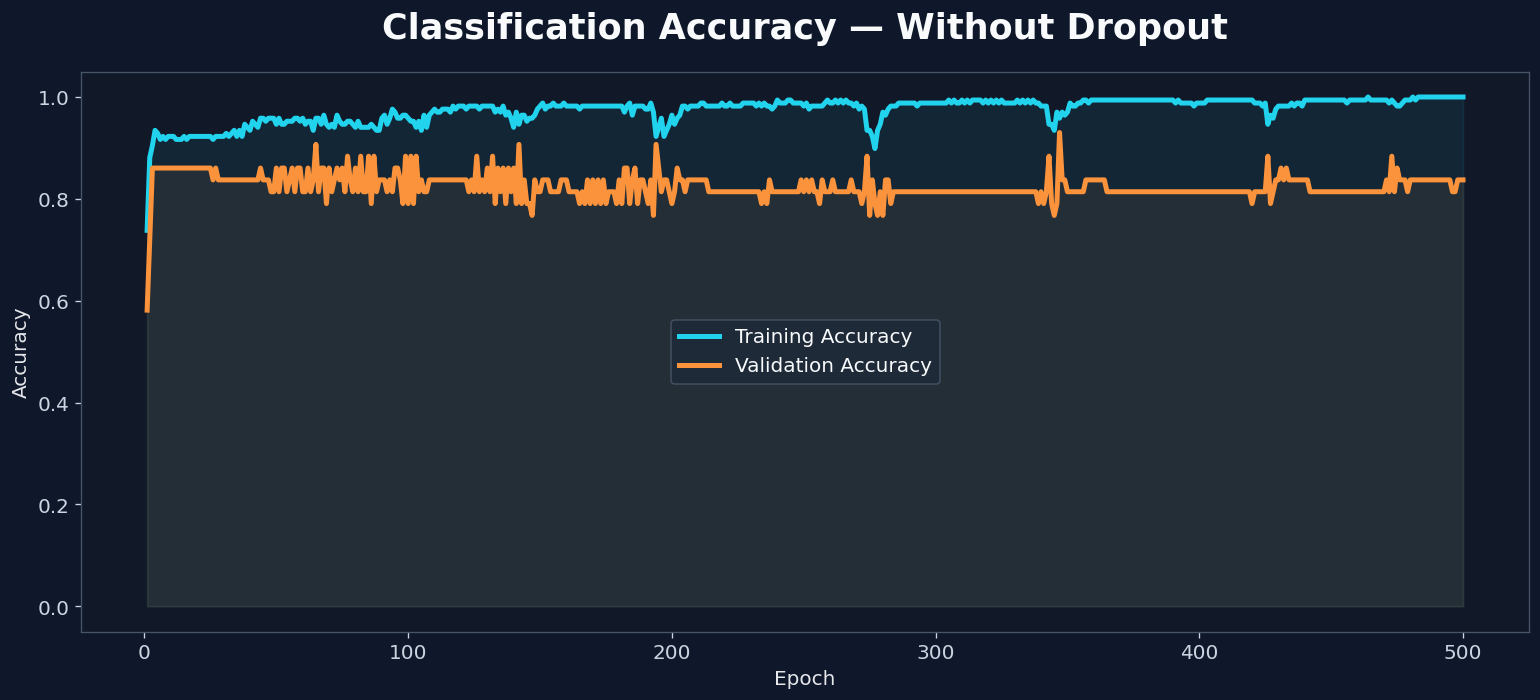

In [ ]:
fig, ax = plt.subplots(figsize=(13, 6))

ax.plot(
    epochs_cls,
    history_cls_base.history["accuracy"],
    color=COLORS["cyan"],
    linewidth=3,
    label="Training Accuracy"
)

ax.plot(
    epochs_cls,
    history_cls_base.history["val_accuracy"],
    color=COLORS["orange"],
    linewidth=3,
    label="Validation Accuracy"
)

ax.fill_between(
    epochs_cls,
    history_cls_base.history["accuracy"],
    alpha=0.08,
    color=COLORS["cyan"]
)

ax.fill_between(
    epochs_cls,
    history_cls_base.history["val_accuracy"],
    alpha=0.08,
    color=COLORS["orange"]
)

ax.set_title(
    "Classification Accuracy — Without Dropout",
    fontsize=21,
    pad=20
)

ax.set_xlabel("Epoch")
ax.set_ylabel("Accuracy")

ax.legend(frameon=True)

plt.tight_layout()
plt.show()

In [ ]:
def plot_decision_boundary(model, X_data, y_data, title):

    x_min = X_data[:, 0].min() - 0.08
    x_max = X_data[:, 0].max() + 0.08
    y_min = X_data[:, 1].min() - 0.08
    y_max = X_data[:, 1].max() + 0.08

    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 600),
        np.linspace(y_min, y_max, 600)
    )

    grid = np.column_stack([
        xx.ravel(),
        yy.ravel()
    ])

    probabilities = model.predict(
        grid,
        verbose=0
    ).reshape(xx.shape)

    fig, ax = plt.subplots(figsize=(10, 9))

    contour = ax.contourf(
        xx,
        yy,
        probabilities,
        levels=np.linspace(0, 1, 41),
        cmap="coolwarm",
        alpha=0.30
    )

    boundary = ax.contour(
        xx,
        yy,
        probabilities,
        levels=[0.5],
        colors=[COLORS["yellow"]],
        linewidths=3
    )

    ax.scatter(
        X_data[y_data.astype(int) == 0, 0],
        X_data[y_data.astype(int) == 0, 1],
        s=65,
        c=COLORS["cyan"],
        edgecolor=COLORS["white"],
        linewidth=0.8,
        alpha=0.9,
        label="Class 0"
    )

    ax.scatter(
        X_data[y_data.astype(int) == 1, 0],
        X_data[y_data.astype(int) == 1, 1],
        s=65,
        c=COLORS["pink"],
        edgecolor=COLORS["white"],
        linewidth=0.8,
        alpha=0.9,
        label="Class 1"
    )

    ax.set_title(
        title,
        fontsize=21,
        pad=20
    )

    ax.set_xlabel("Feature 1")
    ax.set_ylabel("Feature 2")

    ax.legend(frameon=True)

    colorbar = fig.colorbar(
        contour,
        ax=ax,
        pad=0.02
    )

    colorbar.set_label(
        "Predicted Probability",
        color=COLORS["white"]
    )

    plt.tight_layout()
    plt.show()

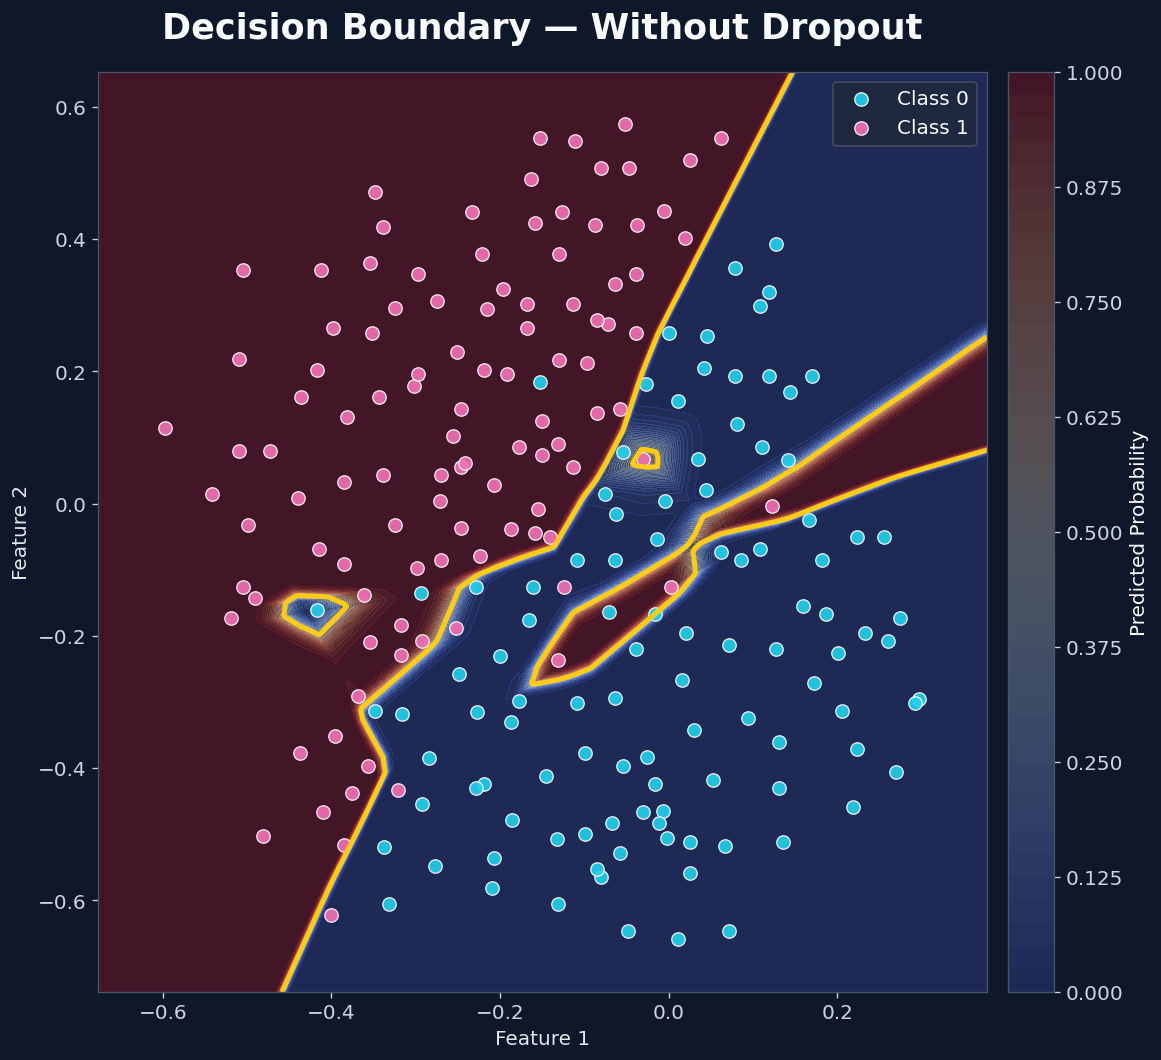

In [ ]:
plot_decision_boundary(
    model_cls_base,
    X,
    y,
    "Decision Boundary — Without Dropout"
)

In [ ]:
cls_dropout_rate = 0.50

model_cls_dropout = Sequential([
    Dense(128, input_dim=2, activation="relu"),
    Dropout(cls_dropout_rate),
    Dense(128, activation="relu"),
    Dropout(cls_dropout_rate),
    Dense(1, activation="sigmoid")
])

model_cls_dropout.compile(
    optimizer=Adam(learning_rate=0.01),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

model_cls_dropout.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_9 (Dense)                 │ (None, 128)            │           384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,025 (66.50 KB)

 Trainable params: 17,025 (66.50 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history_cls_dropout = model_cls_dropout.fit(
    X,
    y,
    epochs=500,
    validation_split=0.2,
    verbose=0
)

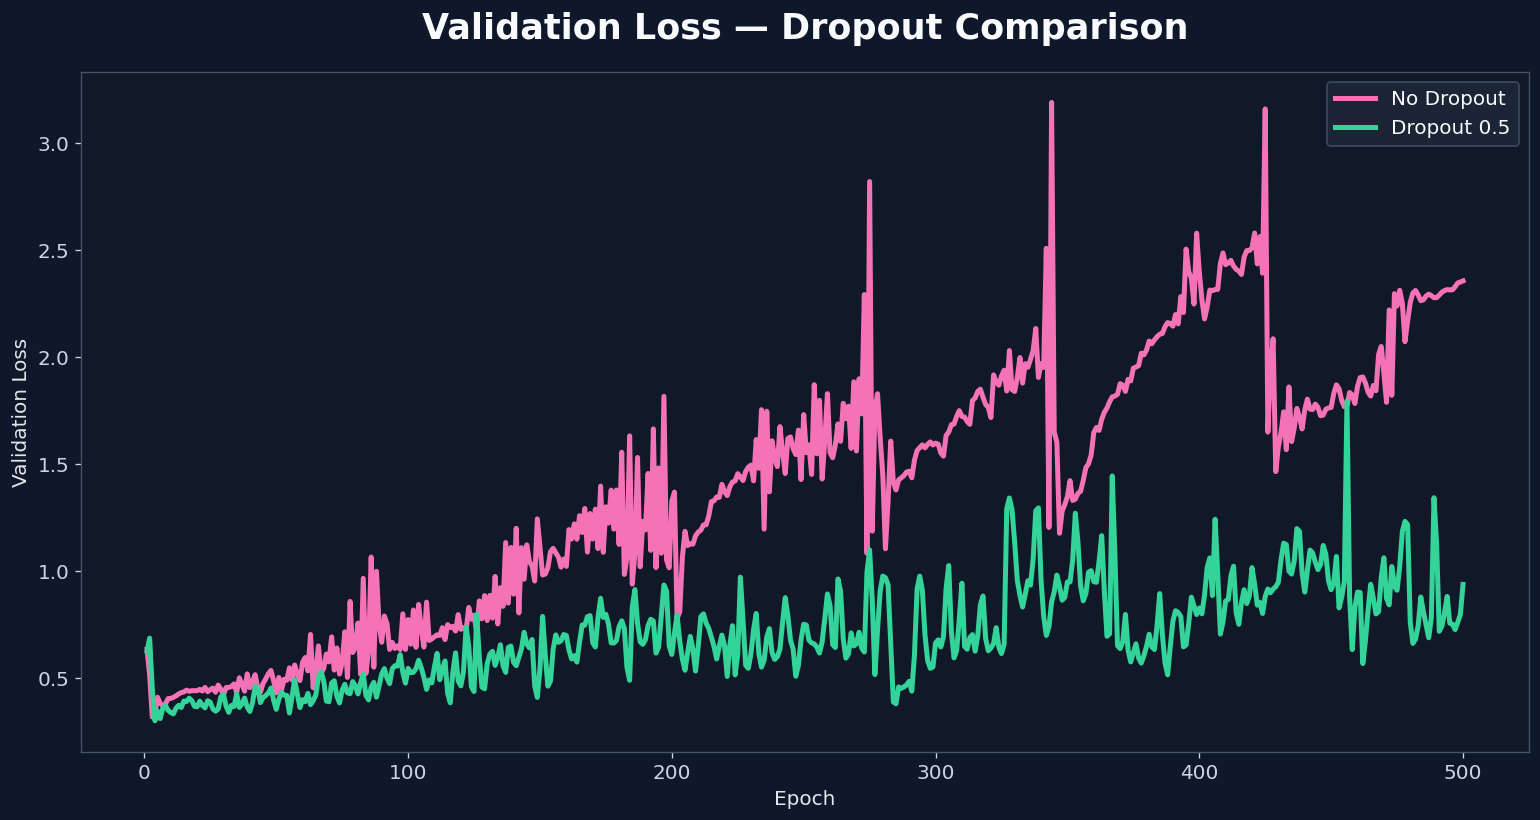

In [ ]:
epochs_drop_cls = np.arange(
    1,
    len(history_cls_dropout.history["loss"]) + 1
)

fig, ax = plt.subplots(figsize=(13, 7))

ax.plot(
    epochs_cls,
    history_cls_base.history["val_loss"],
    color=COLORS["pink"],
    linewidth=3,
    label="No Dropout"
)

ax.plot(
    epochs_drop_cls,
    history_cls_dropout.history["val_loss"],
    color=COLORS["green"],
    linewidth=3,
    label="Dropout 0.5"
)

ax.set_title(
    "Validation Loss — Dropout Comparison",
    fontsize=21,
    pad=20
)

ax.set_xlabel("Epoch")
ax.set_ylabel("Validation Loss")

ax.legend(frameon=True)

plt.tight_layout()
plt.show()

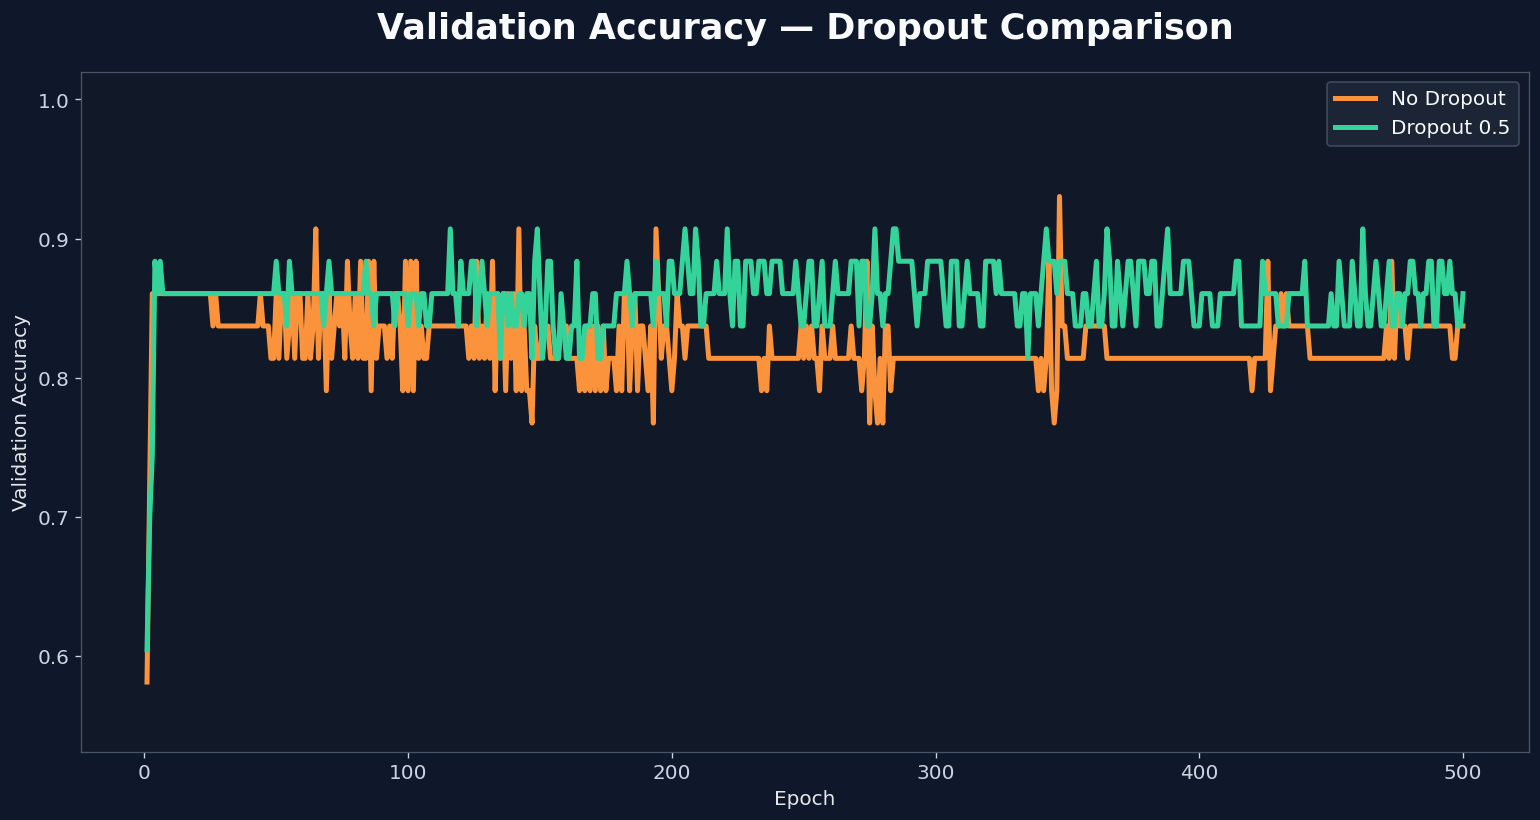

In [ ]:
fig, ax = plt.subplots(figsize=(13, 7))

ax.plot(
    epochs_cls,
    history_cls_base.history["val_accuracy"],
    color=COLORS["orange"],
    linewidth=3,
    label="No Dropout"
)

ax.plot(
    epochs_drop_cls,
    history_cls_dropout.history["val_accuracy"],
    color=COLORS["green"],
    linewidth=3,
    label="Dropout 0.5"
)

ax.set_title(
    "Validation Accuracy — Dropout Comparison",
    fontsize=21,
    pad=20
)

ax.set_xlabel("Epoch")
ax.set_ylabel("Validation Accuracy")

ax.set_ylim(
    max(
        0,
        min(
            min(history_cls_base.history["val_accuracy"]),
            min(history_cls_dropout.history["val_accuracy"])
        ) - 0.05
    ),
    1.02
)

ax.legend(frameon=True)

plt.tight_layout()
plt.show()

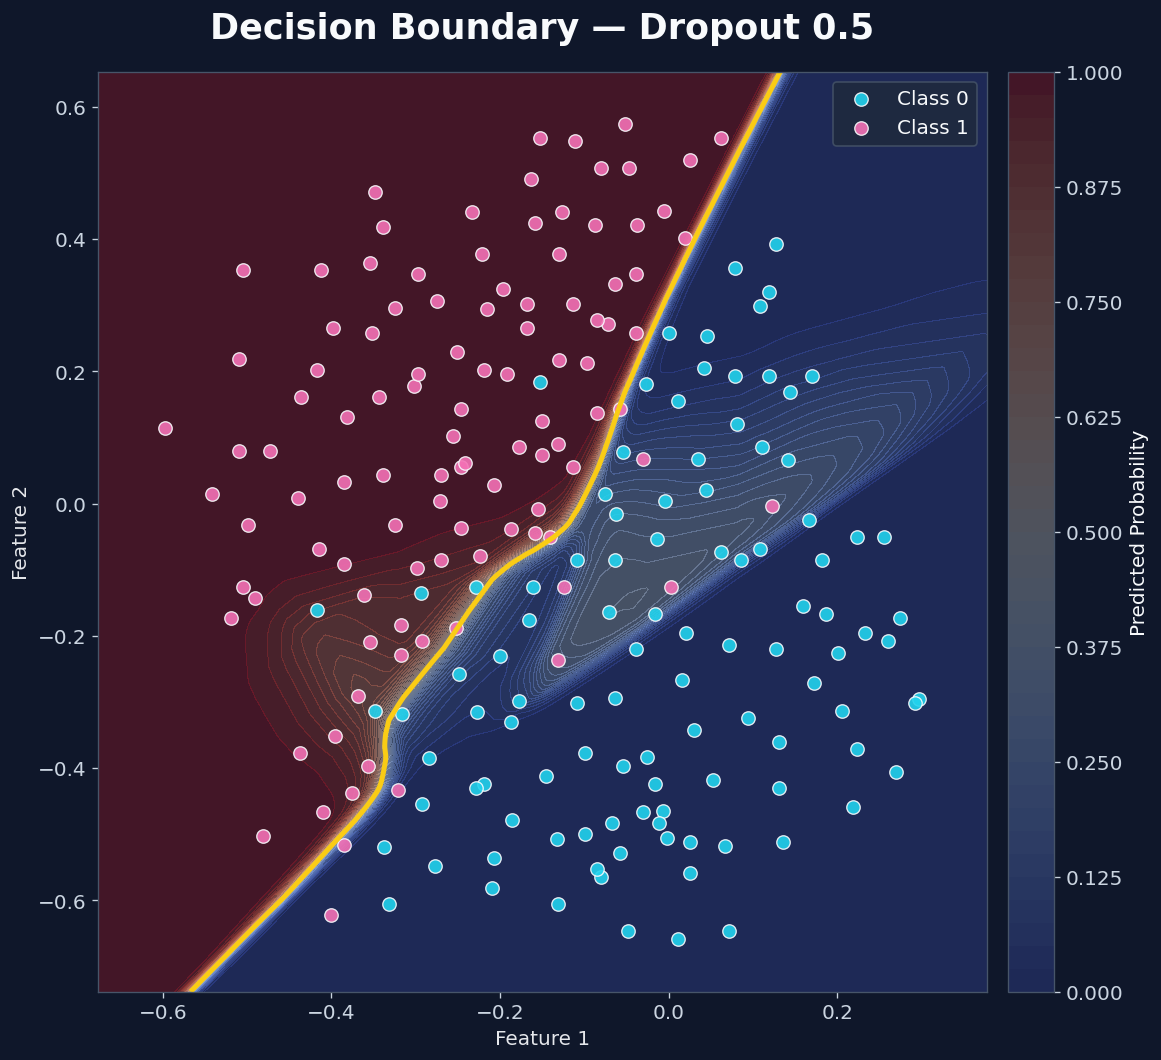

In [ ]:
plot_decision_boundary(
    model_cls_dropout,
    X,
    y,
    "Decision Boundary — Dropout 0.5"
)

In [ ]:
validation_size = int(len(X) * 0.2)

split_index = len(X) - validation_size

X_val = X[split_index:]
y_val = y[split_index:]

probabilities = model_cls_dropout.predict(
    X_val,
    verbose=0
).ravel()

predictions = (
    probabilities >= 0.5
).astype(int)

accuracy = accuracy_score(
    y_val,
    predictions
)

precision = precision_score(
    y_val,
    predictions,
    zero_division=0
)

recall = recall_score(
    y_val,
    predictions,
    zero_division=0
)

f1 = f1_score(
    y_val,
    predictions,
    zero_division=0
)

print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1 Score  : {f1:.4f}")

Accuracy  : 0.8571
Precision : 0.8667
Recall    : 0.7647
F1 Score  : 0.8125


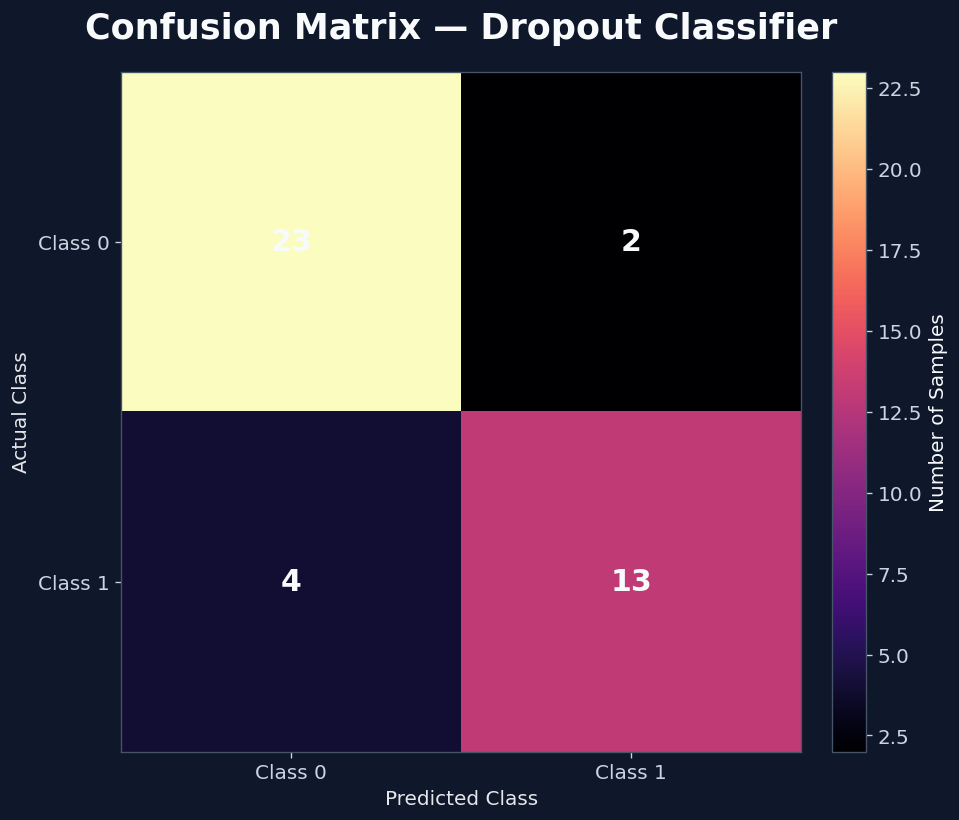

In [ ]:
cm = confusion_matrix(
    y_val,
    predictions
)

fig, ax = plt.subplots(figsize=(8, 7))

heatmap = ax.imshow(
    cm,
    cmap="magma"
)

ax.set_title(
    "Confusion Matrix — Dropout Classifier",
    fontsize=21,
    pad=20
)

ax.set_xlabel("Predicted Class")
ax.set_ylabel("Actual Class")

ax.set_xticks([0, 1])
ax.set_yticks([0, 1])

ax.set_xticklabels(["Class 0", "Class 1"])
ax.set_yticklabels(["Class 0", "Class 1"])

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(
            j,
            i,
            str(cm[i, j]),
            ha="center",
            va="center",
            fontsize=18,
            fontweight="bold",
            color=COLORS["white"]
        )

cbar = fig.colorbar(
    heatmap,
    ax=ax,
    fraction=0.046,
    pad=0.04
)

cbar.set_label(
    "Number of Samples",
    color=COLORS["white"]
)

plt.tight_layout()
plt.show()

In [ ]:
dropout_rates = [0.0, 0.2, 0.3, 0.5, 0.7]

experiment_results = {
    "rate": [],
    "train_accuracy": [],
    "validation_accuracy": [],
    "train_loss": [],
    "validation_loss": []
}

for rate in dropout_rates:

    experiment_model = Sequential([
        Dense(128, input_dim=2, activation="relu"),
        Dropout(rate),
        Dense(128, activation="relu"),
        Dropout(rate),
        Dense(1, activation="sigmoid")
    ])

    experiment_model.compile(
        optimizer=Adam(learning_rate=0.01),
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )

    experiment_history = experiment_model.fit(
        X,
        y,
        epochs=500,
        validation_split=0.2,
        verbose=0
    )

    experiment_results["rate"].append(rate)

    experiment_results["train_accuracy"].append(
        experiment_history.history["accuracy"][-1]
    )

    experiment_results["validation_accuracy"].append(
        experiment_history.history["val_accuracy"][-1]
    )

    experiment_results["train_loss"].append(
        experiment_history.history["loss"][-1]
    )

    experiment_results["validation_loss"].append(
        experiment_history.history["val_loss"][-1]
    )

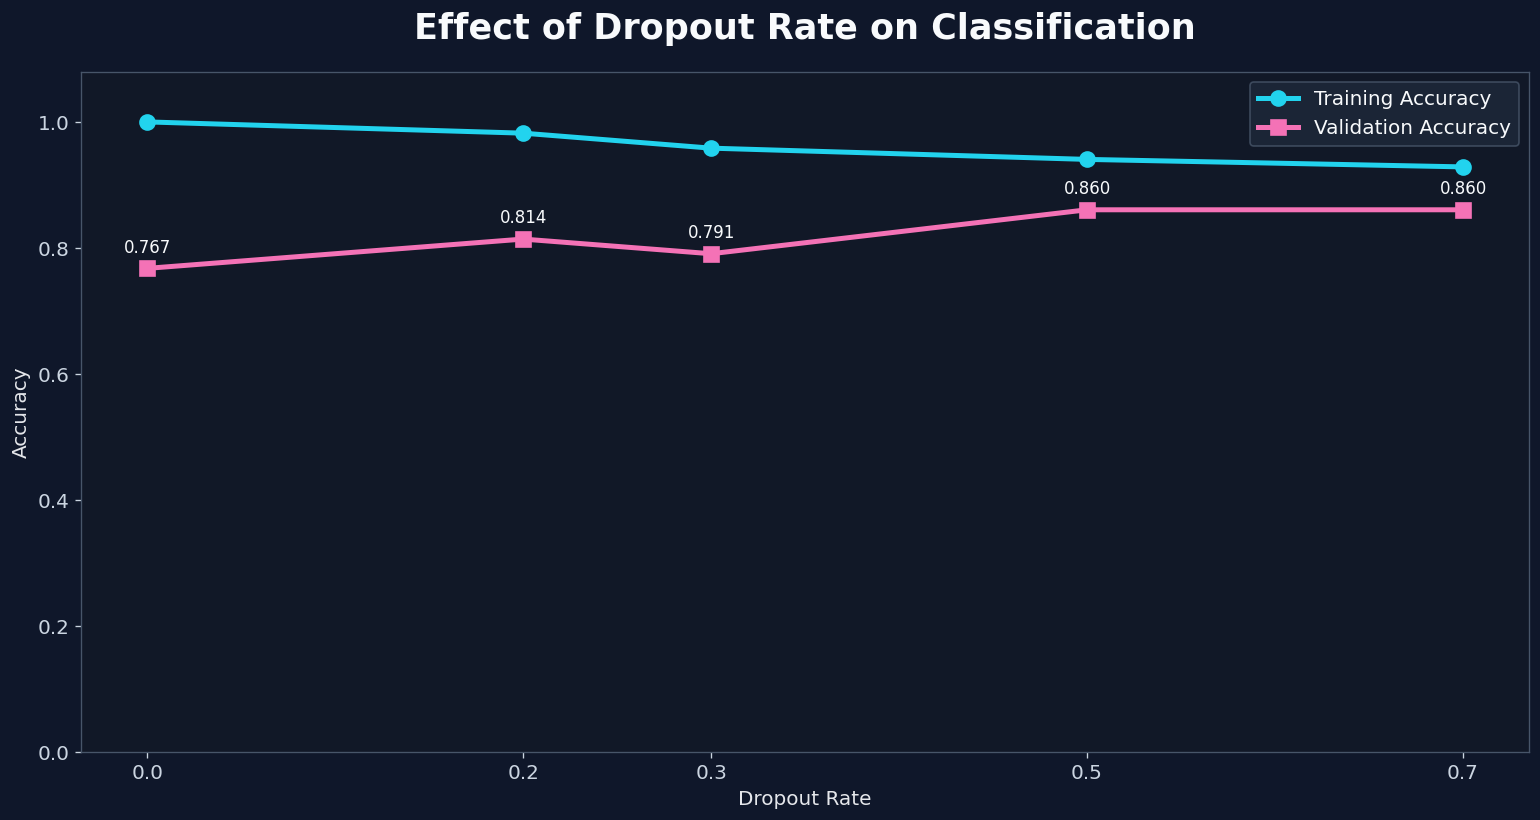

In [ ]:
fig, ax = plt.subplots(figsize=(13, 7))

ax.plot(
    experiment_results["rate"],
    experiment_results["train_accuracy"],
    marker="o",
    markersize=9,
    linewidth=3,
    color=COLORS["cyan"],
    label="Training Accuracy"
)

ax.plot(
    experiment_results["rate"],
    experiment_results["validation_accuracy"],
    marker="s",
    markersize=9,
    linewidth=3,
    color=COLORS["pink"],
    label="Validation Accuracy"
)

for x, y_value in zip(
    experiment_results["rate"],
    experiment_results["validation_accuracy"]
):
    ax.annotate(
        f"{y_value:.3f}",
        (x, y_value),
        xytext=(0, 10),
        textcoords="offset points",
        ha="center",
        color=COLORS["white"],
        fontsize=10
    )

ax.set_title(
    "Effect of Dropout Rate on Classification",
    fontsize=21,
    pad=20
)

ax.set_xlabel("Dropout Rate")
ax.set_ylabel("Accuracy")

ax.set_xticks(dropout_rates)
ax.set_ylim(0, 1.08)

ax.legend(frameon=True)

plt.tight_layout()
plt.show()

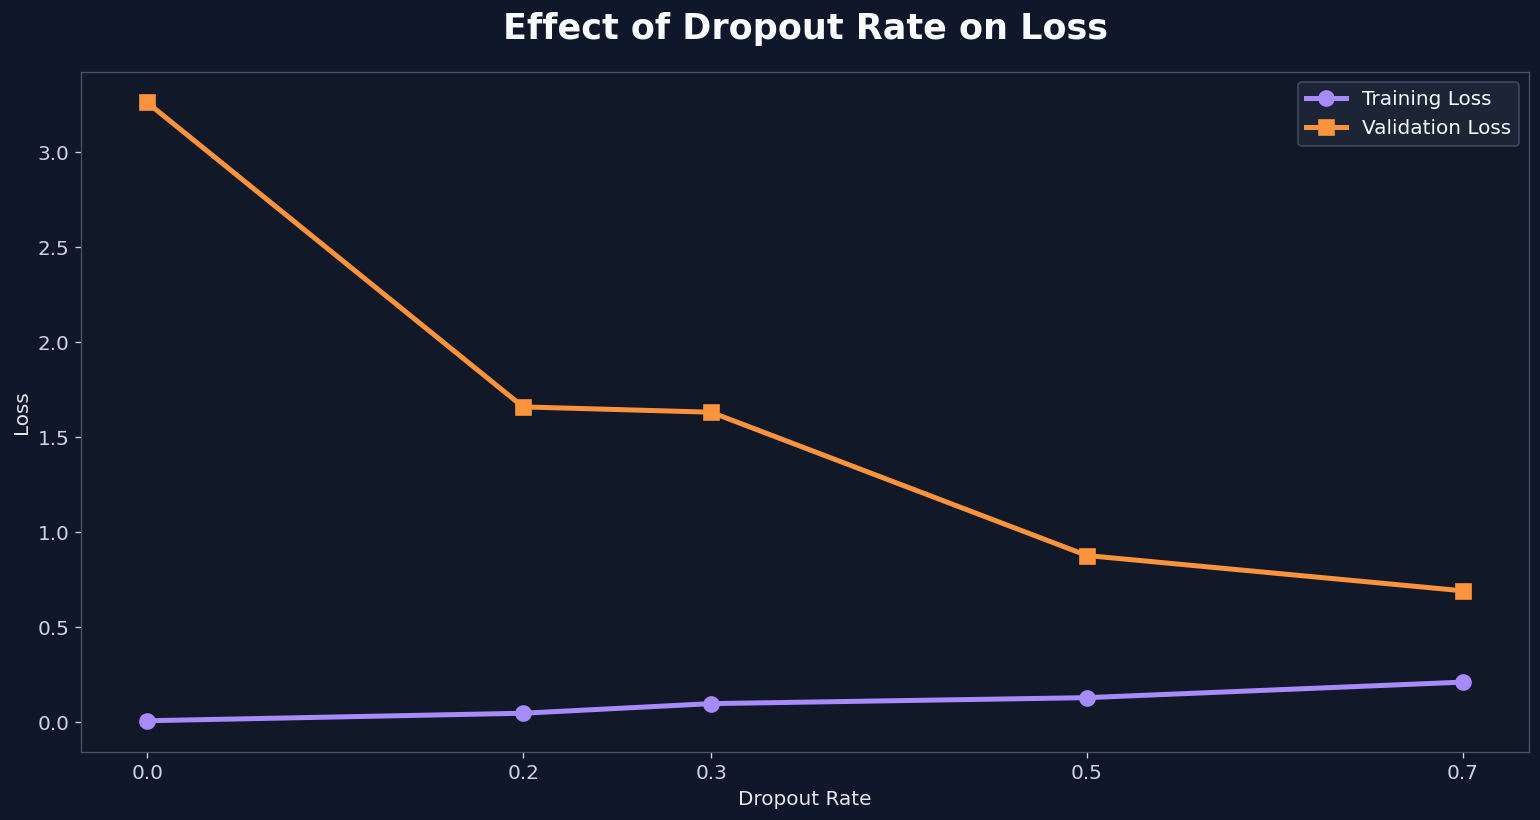

In [ ]:
fig, ax = plt.subplots(figsize=(13, 7))

ax.plot(
    experiment_results["rate"],
    experiment_results["train_loss"],
    marker="o",
    markersize=9,
    linewidth=3,
    color=COLORS["purple"],
    label="Training Loss"
)

ax.plot(
    experiment_results["rate"],
    experiment_results["validation_loss"],
    marker="s",
    markersize=9,
    linewidth=3,
    color=COLORS["orange"],
    label="Validation Loss"
)

ax.set_title(
    "Effect of Dropout Rate on Loss",
    fontsize=21,
    pad=20
)

ax.set_xlabel("Dropout Rate")
ax.set_ylabel("Loss")

ax.set_xticks(dropout_rates)

ax.legend(frameon=True)

plt.tight_layout()
plt.show()

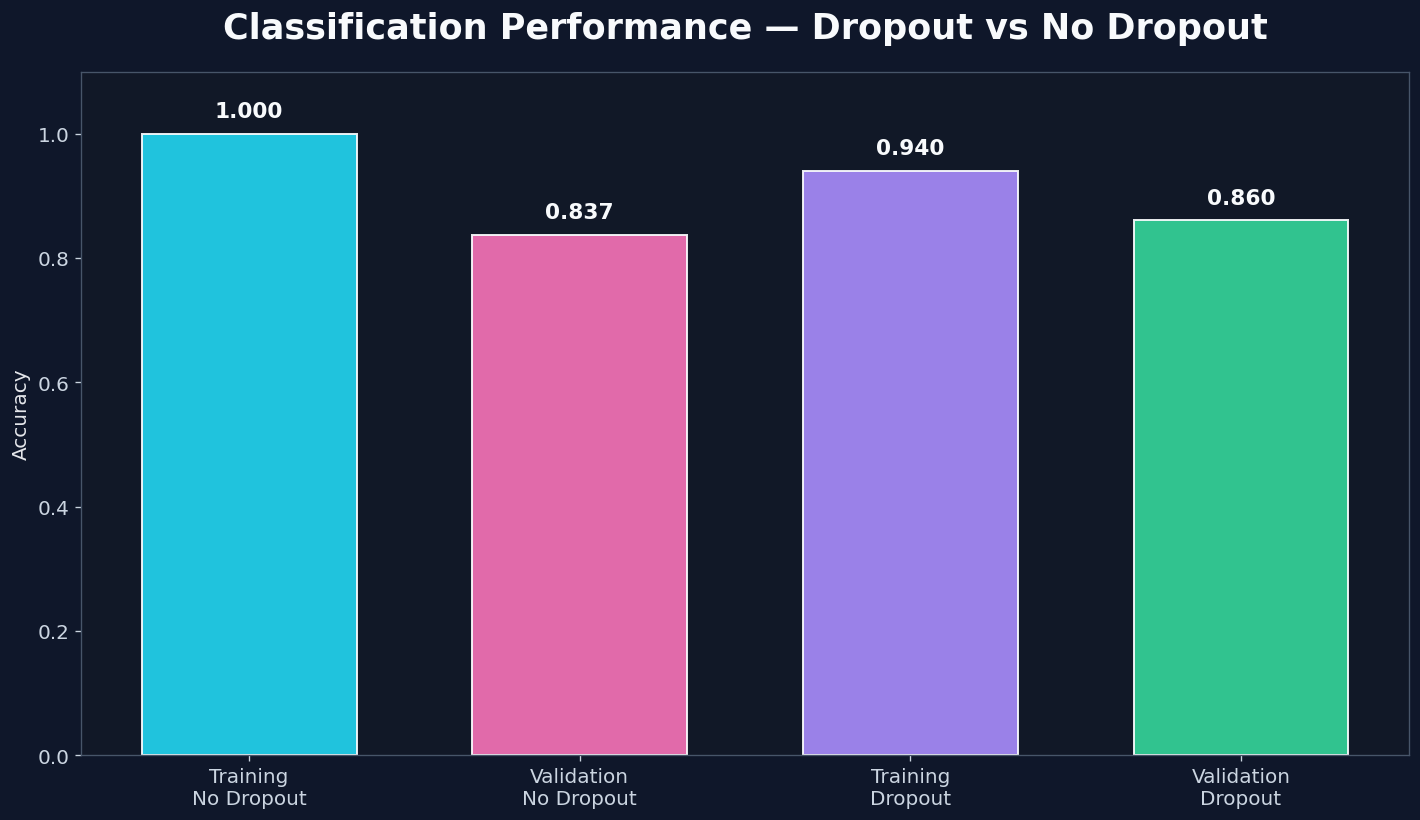

In [ ]:
base_train_acc = history_cls_base.history["accuracy"][-1]
base_val_acc = history_cls_base.history["val_accuracy"][-1]

drop_train_acc = history_cls_dropout.history["accuracy"][-1]
drop_val_acc = history_cls_dropout.history["val_accuracy"][-1]

labels = [
    "Training\nNo Dropout",
    "Validation\nNo Dropout",
    "Training\nDropout",
    "Validation\nDropout"
]

values = [
    base_train_acc,
    base_val_acc,
    drop_train_acc,
    drop_val_acc
]

bar_colors = [
    COLORS["cyan"],
    COLORS["pink"],
    COLORS["purple"],
    COLORS["green"]
]

fig, ax = plt.subplots(figsize=(12, 7))

bars = ax.bar(
    labels,
    values,
    color=bar_colors,
    width=0.65,
    alpha=0.92,
    edgecolor=COLORS["white"],
    linewidth=1.2
)

for bar, value in zip(bars, values):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.02,
        f"{value:.3f}",
        ha="center",
        va="bottom",
        fontsize=13,
        fontweight="bold"
    )

ax.set_ylim(0, 1.10)

ax.set_title(
    "Classification Performance — Dropout vs No Dropout",
    fontsize=21,
    pad=20
)

ax.set_ylabel("Accuracy")

plt.tight_layout()
plt.show()